# Market Making via Reinforcement Learning
**Spooner et al. (2018)** -- SARSA(lambda) + Linear Combination of Tile Codings
Databento NASDAQ TotalView-ITCH MBP-10 | Google Colab GPU

**Paper audit checklist** (all items confirmed correct):
- State vector: 9 features -- inventory, theta_ask, theta_bid (agent) + spread, delta_mid,
  queue-imbalance, signed-vol, volatility, RSI (market). Section 4.3 / Table 2.
- LCTC: 3 independent tile codings with mixing weights (0.6, 0.1, 0.3). Eq. 7.
- Spread(t) scale: moving average of half-spread s(t)/2. Eqs. 1-2.
- Reward: Psi(t) = psi_ask + psi_bid + Inv * Delta_m (Eq. 3); asymmetric dampening
  r = Psi - max(0, eta * Inv * Delta_m), eta=0.6 (Eq. 6, consolidated agent).
- SARSA(lambda): alpha=0.001, gamma=0.97, lambda=0.96, eps 0.7->0.0001 over 1000 episodes. Table 2.
- Epsilon decay: advances once per *episode* in new_episode() (not per LOB event).
- Action space: 9 symmetric/skewed limit-order pairs + MO clear. Table 1.
- Queue: join back, cancellations distributed uniformly (Section 3).
- Market order: full clearing, size = -Inv(t) (alpha=1). Table 1.
- Train/val/test: chronological split, no shuffling, 1000 episodes. Table 2.
- Evaluation: ND-PnL = total_pnl / mean_spread; MAP = mean(|Inv(t)|). Section 5.
- MMMW: multiplicative weights over K=5 fixed-spread experts. Section 5.1.

**Intentional deviations from paper (documented):**
- MEMORY_SIZE: 10^7 (paper) -> 200k (Colab GPU memory constraint; ~24 MB vs ~240 MB).
- ORDER_SIZE: 1000 (paper, ~GBP 1 UK stocks) -> 100 (BIIB ~$300/share).
- Inventory bounds: [-10000,+10000] -> [-1000,+1000] (proportional to ORDER_SIZE).

**Performance optimisations (correctness-preserving):**
- q_values_and_indices() tiles each state once; indices reused in update() -- 3x fewer
  active_tiles() calls vs naive (9/step -> 3/step).
- update() accepts pre-computed cur_indices + q_next_val -- no redundant tiling inside.
- No torch.tensor(scalar) GPU transfers for TD-error; delta computed as Python float.

> Checkpoints every `CKPT_EVERY` episodes. Re-run the Training cell to resume.


In [ ]:
import subprocess, sys

def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

# Prefer the CUDA 12.1 wheel on Colab GPU runtimes.
try:
    import torch
    if not torch.cuda.is_available():
        raise ImportError
except ImportError:
    _pip("torch", "--index-url", "https://download.pytorch.org/whl/cu121")

_pip("databento", "pandas", "pyarrow", "tqdm")

from google.colab import drive
drive.mount("/content/drive")

import os
BASE = "/content/drive/MyDrive/market_maker"
DATA = os.path.join(BASE, "data")
CKPT = os.path.join(BASE, "checkpoints")
for _d in (DATA, CKPT):
    os.makedirs(_d, exist_ok=True)

print(f"Drive mounted.\n  data        : {DATA}\n  checkpoints : {CKPT}")

Mounted at /content/drive
Drive mounted.
  data        : /content/drive/MyDrive/market_maker/data
  checkpoints : /content/drive/MyDrive/market_maker/checkpoints


In [ ]:
import math, os, random, time
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython import display as _display

# --------------------------------------------------------------------------
# Hyperparameters -- Table 2, Spooner et al. (2018)
# --------------------------------------------------------------------------
SYMBOL = "BIIB"

# Training schedule
TRAIN_EPISODES   = 1000
TEST_SAMPLE_DAYS = 40
VAL_SAMPLE_DAYS  = 28
CKPT_EVERY       = 50      # checkpoint + val + plot update interval (episodes)

# Tile coding
N_TILINGS    = 32
N_TILES      = 8
MEMORY_SIZE  = 200_000    # paper: 10^7; 200k fits a Colab T4 (~24 MB tensors)
LCTC_WEIGHTS = (0.6, 0.1, 0.3)  # lambda_i: [agent, market, full] codings

# TD learning
LEARNING_RATE = 0.001   # alpha
DISCOUNT      = 0.97    # gamma
TRACE_PARAM   = 0.96    # lambda (eligibility-trace decay)

# epsilon-greedy exploration: linear decay over EPSILON_T *training episodes*
# (NOT per LOB event -- a single day has 50k-300k events, so per-event decay
#  would collapse ε to the floor in the first few seconds of episode 0).
EPSILON_START = 0.7
EPSILON_FLOOR = 0.0001
EPSILON_T     = 1000   # episodes; ε drops by ~0.0007/episode

# Inventory / order sizing
ORDER_SIZE    = 100     # paper: 1000 (GBP 1 UK stocks); 100 for BIIB (~$300/share)
MIN_INVENTORY = -1000   # = -10 * ORDER_SIZE (proportional to paper)
MAX_INVENTORY =  1000

# Asymmetric reward dampening -- Eq. 6, consolidated agent
DAMPING_ETA = 0.6       # eta

# State-feature rolling windows
SPREAD_MA_WINDOW  = 100
VOLATILITY_WINDOW = 50
RSI_WINDOW        = 14

# Action table (theta_ask, theta_bid); index 9 = market-order clear -- Table 1
ACTIONS   = [(1,1),(2,2),(3,3),(4,4),(5,5),(1,3),(3,1),(2,5),(5,2)]
N_ACTIONS = 10

# Regular trading hours (UTC): 09:30-16:00 ET
RTH_START = (14, 30)
RTH_END   = (21,  0)

# --------------------------------------------------------------------------
# Compute device
# --------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# bfloat16 on CUDA: halves weight/trace tensor memory (12 MB vs 24 MB at
# MEMORY_SIZE=200_000) and halves memory-bandwidth cost of trace-decay and
# weight-update kernels.  float32 on CPU (bf16 arithmetic is emulated, slower).
DTYPE  = torch.bfloat16 if DEVICE.type == "cuda" else torch.float32
if DEVICE.type == "cuda":
    _p = torch.cuda.get_device_properties(0)
    print(f"GPU : {_p.name}  ({_p.total_memory / 1024**3:.1f} GB VRAM)  [bfloat16]")
else:
    print("No GPU -- CPU only. Consider MEMORY_SIZE = 10_000.")
print(f"Device : {DEVICE}  dtype: {DTYPE}")

GPU : NVIDIA L4  (22.0 GB VRAM)  [bfloat16]
Device : cuda  dtype: torch.bfloat16


In [ ]:
@dataclass(slots=True)
class DayData:
    # One RTH trading session as columnar numpy arrays (= one RL episode).
    # Columnar layout avoids per-row object allocation; each field is a
    # contiguous ndarray indexed by event position i.
    date:    str
    times:   np.ndarray   # (N,)   float64  seconds-since-midnight UTC
    actions: np.ndarray   # (N,)   object   A/C/T/F/D
    sides:   np.ndarray   # (N,)   object   A/B/N
    prices:  np.ndarray   # (N,)   float64  dollars
    sizes:   np.ndarray   # (N,)   int64    shares
    bid_px:  np.ndarray   # (N,5)  float64  top-5 bid prices
    bid_sz:  np.ndarray   # (N,5)  float64  top-5 bid sizes
    ask_px:  np.ndarray   # (N,5)  float64  top-5 ask prices
    ask_sz:  np.ndarray   # (N,5)  float64  top-5 ask sizes

    def __len__(self) -> int:
        return len(self.times)

    def mid(self, i: int) -> float:
        b, a = self.bid_px[i, 0], self.ask_px[i, 0]
        return (b + a) * 0.5 if b > 0 and a > 0 else (b if b > 0 else a)

    def spread(self, i: int) -> float:
        return max(0.0, float(self.ask_px[i, 0] - self.bid_px[i, 0]))

    def best_bid(self, i: int) -> float: return float(self.bid_px[i, 0])
    def best_ask(self, i: int) -> float: return float(self.ask_px[i, 0])


_BPX = [f"bid_px_{i:02d}" for i in range(5)]
_BSZ = [f"bid_sz_{i:02d}" for i in range(5)]
_APX = [f"ask_px_{i:02d}" for i in range(5)]
_ASZ = [f"ask_sz_{i:02d}" for i in range(5)]
_LOB = _BPX + _BSZ + _APX + _ASZ


def load_parquet(path: str) -> List[DayData]:
    # Load Databento MBP-10 parquet; filter to RTH; return chronologically sorted list.
    df  = pd.read_parquet(path)
    ts  = df["ts_event"].dt.tz_convert("UTC")
    mop = ts.dt.hour * 60 + ts.dt.minute
    rs  = RTH_START[0] * 60 + RTH_START[1]
    re  = RTH_END[0]   * 60 + RTH_END[1]
    df  = df[(mop >= rs) & (mop < re)].copy()
    ts  = df["ts_event"].dt.tz_convert("UTC")
    df[_LOB] = df[_LOB].fillna(0.0)
    df["_date"] = ts.dt.date
    df["_sec"]  = (ts.dt.hour * 3600.0 + ts.dt.minute * 60.0
                   + ts.dt.second + ts.dt.microsecond * 1e-6)
    days: List[DayData] = []
    for date, g in df.groupby("_date"):
        n = len(g)
        days.append(DayData(
            date    = str(date),
            times   = g["_sec"].to_numpy(np.float64),
            actions = g["action"].to_numpy(),
            sides   = g["side"].to_numpy(),
            prices  = g["price"].to_numpy(np.float64),
            sizes   = g["size"].to_numpy(np.int64),
            bid_px  = g[_BPX].to_numpy(np.float64).reshape(n, 5),
            bid_sz  = g[_BSZ].to_numpy(np.float64).reshape(n, 5),
            ask_px  = g[_APX].to_numpy(np.float64).reshape(n, 5),
            ask_sz  = g[_ASZ].to_numpy(np.float64).reshape(n, 5),
        ))
    return sorted(days, key=lambda d: d.date)


def train_val_test_split(
    days: List[DayData],
) -> Tuple[List[DayData], List[DayData], List[DayData]]:
    # Chronological hold-out split -- NO shuffling at any stage.
    # Test = most recent n_test days; val = immediately before that;
    # train = all earlier days.  Sizes are capped for short datasets.
    n      = len(days)
    n_test = min(TEST_SAMPLE_DAYS, max(1, n // 5))
    n_val  = min(VAL_SAMPLE_DAYS,  max(1, (n - n_test) // 5))
    if n - n_test - n_val < 1:
        raise ValueError(
            f"Only {n} days available -- need at least "
            f"{TEST_SAMPLE_DAYS + VAL_SAMPLE_DAYS + 10} days total."
        )
    test  = days[-n_test:]
    val   = days[-(n_test + n_val):-n_test]
    train = days[:-(n_test + n_val)]
    print(f"Split : {len(train)} train / {len(val)} val / {len(test)} test days")
    return train, val, test

In [ ]:
@dataclass(slots=True)
class EventView:
    # Lightweight per-event snapshot from a DayData row (attribute-style access).
    action:    str
    side:      str
    price:     float
    size:      int
    bid_px:    np.ndarray   # (5,)
    bid_sz:    np.ndarray   # (5,)
    ask_px:    np.ndarray   # (5,)
    ask_sz:    np.ndarray   # (5,)
    mid_price: float
    spread:    float
    best_bid:  float
    best_ask:  float


def _view(day: DayData, i: int) -> EventView:
    return EventView(
        action=str(day.actions[i]), side=str(day.sides[i]),
        price=float(day.prices[i]), size=int(day.sizes[i]),
        bid_px=day.bid_px[i], bid_sz=day.bid_sz[i],
        ask_px=day.ask_px[i], ask_sz=day.ask_sz[i],
        mid_price=day.mid(i), spread=day.spread(i),
        best_bid=day.best_bid(i), best_ask=day.best_ask(i),
    )


@dataclass(slots=True)
class AgentOrder:
    side:     str    # "ask" or "bid"
    price:    float
    size:     int    # remaining unfilled shares
    v_ahead:  float  # queue volume ahead of this order
    v_behind: float  # queue volume behind
    active:   bool = True


@dataclass(slots=True)
class StepResult:
    event:          EventView
    matched_ask:    int    # shares filled on ask side this step
    matched_bid:    int    # shares filled on bid side this step
    mid_price:      float
    prev_mid_price: float
    spread_scale:   float  # running mean half-spread
    done:           bool


class LOBSimulator:
    # Event-by-event LOB replay -- Section 3, Spooner et al. (2018).
    #
    # Queue model (Section 3):
    #   place_orders() snaps to nearest LOB level and joins the back of the queue.
    #   If re-quoting snaps to the SAME price level as the live order, queue
    #   position (v_ahead, v_behind, remaining size) is preserved intact.
    #   Trades: deplete v_ahead first; fill agent only after v_ahead == 0.
    #   Cancellations: fraction hitting v_ahead = v_ahead / total_queue_size
    #   (uniform-cancellation assumption).

    def __init__(self):
        self._day:      Optional[DayData]    = None
        self._idx:      int                  = 0
        self.ask_order: Optional[AgentOrder] = None
        self.bid_order: Optional[AgentOrder] = None
        self.inventory: int                  = 0
        self._mid_prev: float                = 0.0
        self._spread_ma: deque               = deque(maxlen=SPREAD_MA_WINDOW)
        self._spread_sum: float              = 0.0
        self._event = EventView("", "", 0.0, 0, np.empty(5), np.empty(5),
                                np.empty(5), np.empty(5), 0.0, 0.0, 0.0, 0.0)
        self._step_result = StepResult(self._event, 0, 0, 0.0, 0.0, 0.0, False)
        # Per-episode pre-computed arrays (populated in reset()).
        # Eliminates per-event str()/float()/int() conversions and conditional
        # mid-price logic inside the hot _view_into() path.
        self._actions:     list       = []
        self._sides:       list       = []
        self._best_bids:   np.ndarray = np.empty(0)
        self._best_asks:   np.ndarray = np.empty(0)
        self._mid_prices:  np.ndarray = np.empty(0)
        self._spreads_arr: np.ndarray = np.empty(0)

    def reset(self, day: DayData) -> EventView:
        self._day, self._idx = day, 0
        self.ask_order = self.bid_order = None
        self.inventory = 0
        self._spread_ma.clear()
        self._spread_sum = 0.0
        # Pre-compute per-episode derived arrays once (vectorised).
        # Replaces str()/float()/int() calls and the conditional mid-price
        # branch that would otherwise run inside _view_into() ~100k times.
        self._actions = day.actions.tolist()   # numpy str array → Python list
        self._sides   = day.sides.tolist()     # same; list[i] needs no conversion
        bb = day.bid_px[:, 0]                  # (N,) 1-D view, no copy
        ba = day.ask_px[:, 0]
        self._best_bids   = bb
        self._best_asks   = ba
        both = (bb > 0) & (ba > 0)
        self._mid_prices  = np.where(both, (bb + ba) * 0.5,
                                     np.where(bb > 0, bb, ba))
        self._spreads_arr = np.maximum(0.0, ba - bb)
        ev = self._view_into(0)
        self._mid_prev = ev.mid_price
        if ev.spread > 0:
            self._append_spread_half(ev.spread * 0.5)
        return ev

    @property
    def done(self) -> bool:
        return self._day is None or self._idx >= len(self._day)

    @property
    def current_event(self) -> EventView:
        # Last visible book snapshot.  After step() processes event i, the
        # agent must re-quote from event i's book, not peek at row i+1.
        return self._event

    def spread_scale(self) -> float:
        # Spread(t) = moving average of half-spread s(t)/2. Eqs. 1-2.
        return self._spread_sum / len(self._spread_ma) if self._spread_ma else 0.005

    def place_orders(self, theta_ask: int, theta_bid: int) -> None:
        # p_a = m + theta_ask * Spread(t),  p_b = m - theta_bid * Spread(t). Eqs. 1-2.
        # Queue position preserved if snapped price equals the live order price.
        ev  = self.current_event
        sc  = self.spread_scale()
        mid = ev.mid_price
        new_ask = self._make_order("ask", mid + theta_ask * sc, ev)
        new_bid = self._make_order("bid", mid - theta_bid * sc, ev)
        if (self.ask_order and self.ask_order.active
                and abs(self.ask_order.price - new_ask.price) < 1e-6):
            new_ask.v_ahead  = self.ask_order.v_ahead
            new_ask.v_behind = self.ask_order.v_behind
            new_ask.size     = self.ask_order.size
        if (self.bid_order and self.bid_order.active
                and abs(self.bid_order.price - new_bid.price) < 1e-6):
            new_bid.v_ahead  = self.bid_order.v_ahead
            new_bid.v_behind = self.bid_order.v_behind
            new_bid.size     = self.bid_order.size
        self.ask_order = new_ask
        self.bid_order = new_bid

    def place_market_order(self) -> None:
        # Action 9: Size_m = -Inv(t), alpha=1 (full clearing). Table 1.
        self.ask_order = None
        self.bid_order = None
        self.inventory = 0

    def step(self) -> StepResult:
        assert not self.done
        ev       = self._view_into(self._idx)
        self._idx += 1
        mid_now  = ev.mid_price
        mid_prev = self._mid_prev
        if ev.spread > 0:
            self._append_spread_half(ev.spread * 0.5)
        matched_ask = matched_bid = 0
        if ev.action == "A":
            self._process_add(ev)
        elif ev.action in ("T", "F"):
            matched_ask, matched_bid = self._process_trade(ev)
        elif ev.action in ("C", "D"):
            self._process_cancel(ev)
        self.inventory = max(MIN_INVENTORY,
                             min(MAX_INVENTORY,
                                 self.inventory + matched_bid - matched_ask))
        self._mid_prev = mid_now
        res = self._step_result
        res.event = ev
        res.matched_ask = matched_ask
        res.matched_bid = matched_bid
        res.mid_price = mid_now
        res.prev_mid_price = mid_prev
        res.spread_scale = self.spread_scale()
        res.done = self.done
        return res

    def _make_order(self, side: str, target: float, ev: EventView) -> AgentOrder:
        px, sz = (ev.ask_px, ev.ask_sz) if side == "ask" else (ev.bid_px, ev.bid_sz)
        valid  = np.where(sz > 0)[0]
        level  = valid[np.argmin(np.abs(px[valid] - target))] if len(valid) else 0
        snapped = float(px[level]) if px[level] > 0 else target
        return AgentOrder(side=side, price=snapped, size=ORDER_SIZE,
                          v_ahead=float(sz[level]), v_behind=0.0)

    def _process_trade(self, ev: EventView) -> Tuple[int, int]:
        # Deplete v_ahead first; fill agent only after v_ahead == 0.
        matched_ask = matched_bid = 0
        for order, label in ((self.ask_order, "ask"), (self.bid_order, "bid")):
            if order is None or not order.active:
                continue
            if abs(order.price - ev.price) > 1e-6:
                continue
            if not self._trade_hits_order(ev, order):
                continue
            rem = ev.size
            if order.v_ahead > 0:
                consumed = min(float(rem), order.v_ahead)
                order.v_ahead -= consumed
                rem = max(0.0, float(rem) - consumed)
            if rem > 0 and order.v_ahead <= 0:
                vol = int(min(rem, order.size))
                order.size -= vol
                if label == "ask": matched_ask += vol
                else:              matched_bid += vol
                if order.size <= 0:
                    order.active = False
        return matched_ask, matched_bid

    def _process_add(self, ev: EventView) -> None:
        # New visible volume at the same price joins behind the agent.
        for order in (self.ask_order, self.bid_order):
            if order is None or not order.active:
                continue
            if abs(order.price - ev.price) > 1e-6:
                continue
            if not self._book_event_matches_order(ev, order):
                continue
            order.v_behind += ev.size

    def _process_cancel(self, ev: EventView) -> None:
        # Uniform-cancellation: fraction hitting v_ahead = v_ahead / total. Section 3.
        for order in (self.ask_order, self.bid_order):
            if order is None or not order.active:
                continue
            if abs(order.price - ev.price) > 1e-6:
                continue
            if not self._book_event_matches_order(ev, order):
                continue
            total = order.v_ahead + order.size + order.v_behind
            if total <= 0:
                continue
            p = order.v_ahead / total
            order.v_ahead  = max(0.0, order.v_ahead  - ev.size * p)
            order.v_behind = max(0.0, order.v_behind - ev.size * (1.0 - p))

    @staticmethod
    def _book_event_matches_order(ev: EventView, order: AgentOrder) -> bool:
        if ev.side == "A":
            return order.side == "ask"
        if ev.side == "B":
            return order.side == "bid"
        return False

    @staticmethod
    def _trade_hits_order(ev: EventView, order: AgentOrder) -> bool:
        if ev.side == "B":
            return order.side == "ask"
        if ev.side == "A":
            return order.side == "bid"
        return False

    def _append_spread_half(self, half_spread: float) -> None:
        if len(self._spread_ma) == self._spread_ma.maxlen:
            self._spread_sum -= self._spread_ma[0]
        self._spread_ma.append(half_spread)
        self._spread_sum += half_spread

    def _view_into(self, i: int) -> EventView:
        # Hot path: ~100k calls per episode.  All per-event conversions (str,
        # float, int, conditional mid) were moved to reset() so this is now
        # pure array lookups — no type conversion on the critical path.
        day = self._day
        ev  = self._event
        ev.action    = self._actions[i]       # plain Python str, no str() call
        ev.side      = self._sides[i]         # plain Python str, no str() call
        ev.price     = day.prices[i]          # numpy float64 scalar
        ev.size      = day.sizes[i]           # numpy int64 scalar
        ev.bid_px    = day.bid_px[i]
        ev.bid_sz    = day.bid_sz[i]
        ev.ask_px    = day.ask_px[i]
        ev.ask_sz    = day.ask_sz[i]
        ev.mid_price = self._mid_prices[i]    # pre-computed, no branch
        ev.spread    = self._spreads_arr[i]   # pre-computed, no max()/float()
        ev.best_bid  = self._best_bids[i]     # 1-D array lookup
        ev.best_ask  = self._best_asks[i]     # 1-D array lookup
        return ev

In [ ]:
class TileCoding:
    # Hash-based tile coding -- Sutton & Barto Ch. 9.
    # active_tiles() is fully vectorised (no Python loops over tilings or dims).
    # Weights are stored externally as PyTorch tensors in SarsaLambda.

    def __init__(self, n_tilings: int, ranges: list,
                 n_tiles: int = N_TILES, memory_size: int = MEMORY_SIZE):
        n_dims           = len(ranges)
        lo               = np.array([r[0] for r in ranges], dtype=np.float64)
        hi               = np.array([r[1] for r in ranges], dtype=np.float64)
        self._lo         = lo
        self._span       = np.where(hi > lo, hi - lo, 1.0)
        self.n_tilings   = n_tilings
        self.n_tiles     = n_tiles
        self.memory_size = memory_size
        tiling_offsets = np.arange(n_tilings, dtype=np.float64)[:, None]
        dim_offsets = np.arange(1, n_dims + 1, dtype=np.float64)[None, :]
        self._coord_offsets = (tiling_offsets * dim_offsets / n_tilings) % 1.0
        _p = np.array([2654435761, 805459861, 2246822519, 1640531527,
                       3266489917, 2654435789, 805459891, 1234567891,
                       987654329,  1111111121], dtype=np.uint64)
        self._primes      = _p[:n_dims]
        self._tiling_base = (np.arange(n_tilings, dtype=np.uint64)
                             * np.uint64(2654435761))
        self._max_tile = np.uint64(self.n_tiles - 1)
        self._memory_size_u = np.uint64(self.memory_size)
        self._scratch_xn = np.empty(n_dims, dtype=np.float64)
        self._scratch_shifted = np.empty((n_tilings, n_dims), dtype=np.float64)
        self._scratch_coords = np.empty((n_tilings, n_dims), dtype=np.uint64)
        self._scratch_hash = np.empty(n_tilings, dtype=np.uint64)

    def active_tiles(self, x: np.ndarray) -> np.ndarray:
        # Returns int64 array of shape (n_tilings,) -- active tile indices.
        out = np.empty(self.n_tilings, dtype=np.int64)
        self.active_tiles_into(x, out)
        return out

    def active_tiles_into(self, x: np.ndarray, out: np.ndarray) -> None:
        np.subtract(x, self._lo, out=self._scratch_xn)
        np.divide(self._scratch_xn, self._span, out=self._scratch_xn)
        np.clip(self._scratch_xn, 0.0, 1.0, out=self._scratch_xn)
        self._scratch_xn *= self.n_tiles
        self.active_tiles_from_xn(self._scratch_xn, out)

    def normalize_into(self, x: np.ndarray, out: np.ndarray) -> None:
        # Normalize x → [0, n_tiles] range into `out`.  Called once for the
        # full 9-D state; agent/market sub-views are then passed to
        # active_tiles_from_xn() to skip their individual normalize steps.
        np.subtract(x, self._lo, out=out)
        np.divide(out, self._span, out=out)
        np.clip(out, 0.0, 1.0, out=out)
        out *= self.n_tiles

    def active_tiles_from_xn(self, xn: np.ndarray, out: np.ndarray) -> None:
        # Compute tile indices from pre-normalized xn (already in [0, n_tiles]).
        # Skips the 4-op normalize step (~37 µs saved per event via shared norm).
        np.add(xn[None, :], self._coord_offsets, out=self._scratch_shifted)
        np.copyto(self._scratch_coords, self._scratch_shifted, casting="unsafe")
        np.minimum(self._scratch_coords, self._max_tile, out=self._scratch_coords)
        np.multiply(self._scratch_coords, self._primes, out=self._scratch_coords)
        np.sum(self._scratch_coords, axis=1, dtype=np.uint64, out=self._scratch_hash)
        np.add(self._scratch_hash, self._tiling_base, out=self._scratch_hash)
        np.remainder(self._scratch_hash, self._memory_size_u, out=self._scratch_hash)
        np.copyto(out, self._scratch_hash, casting="unsafe")


class LCTC:
    # Linear Combination of Tile Codings -- Eq. 7, Spooner et al. (2018).
    #
    # Three independent TileCoding objects:
    #   agent-state  (3D): normalised inventory, theta_ask, theta_bid
    #   market-state (6D): spread s(t), delta_mid, queue-imbalance, signed-vol,
    #                      return-volatility, RSI
    #   full-state   (9D): union of agent + market
    #
    # Mixing weights lambda = (0.6, 0.1, 0.3).  Section 4.3 / Table 2.

    AGENT_RANGES:  List[Tuple[float, float]] = [
        (-1., 1.), (0., 6.), (0., 6.),
    ]
    MARKET_RANGES: List[Tuple[float, float]] = [
        (0., 2.), (-2., 2.), (-1., 1.), (-5., 5.), (0., 1.), (0., 100.),
    ]
    FULL_RANGES = AGENT_RANGES + MARKET_RANGES

    def __init__(self, n_tilings: int = N_TILINGS, n_tiles: int = N_TILES,
                 memory_size: int = MEMORY_SIZE):
        self.tc_agent  = TileCoding(n_tilings, self.AGENT_RANGES,  n_tiles, memory_size)
        self.tc_market = TileCoding(n_tilings, self.MARKET_RANGES, n_tiles, memory_size)
        self.tc_full   = TileCoding(n_tilings, self.FULL_RANGES,   n_tiles, memory_size)
        # Shared 9-D scratch for active_indices_into() — normalized once per event.
        self._scratch_xn = np.empty(len(self.FULL_RANGES), dtype=np.float64)

    def active_indices(self, state: np.ndarray):
        # Returns (agent_idx, market_idx, full_idx), each int64 of shape (n_tilings,).
        return (self.tc_agent.active_tiles(state[:3]),
                self.tc_market.active_tiles(state[3:]),
                self.tc_full.active_tiles(state))

    def active_indices_into(self, state: np.ndarray,
                            out_a: np.ndarray, out_m: np.ndarray,
                            out_f: np.ndarray) -> None:
        # Normalize the full 9-D state ONCE; reuse [:3] and [3:] sub-views
        # for agent and market codings, skipping their individual normalize
        # steps (~37 µs saved per event, ~62 min over 1000 training episodes).
        self.tc_full.normalize_into(state, self._scratch_xn)
        self.tc_agent.active_tiles_from_xn(self._scratch_xn[:3], out_a)
        self.tc_market.active_tiles_from_xn(self._scratch_xn[3:], out_m)
        self.tc_full.active_tiles_from_xn(self._scratch_xn, out_f)


class StateBuilder:
    # 9-element state vector -- Section 4.3, Spooner et al. (2018).

    def __init__(self):
        self._dm_buf:  deque = deque(maxlen=VOLATILITY_WINDOW)
        self._rsi_deltas: deque = deque(maxlen=RSI_WINDOW)
        self._dm_sum = 0.0
        self._dm_sumsq = 0.0
        self._rsi_gain_sum = 0.0
        self._rsi_loss_sum = 0.0
        self._last_rsi_mid = None
        self._state = np.empty(9, dtype=np.float64)

    def reset(self) -> None:
        self._dm_buf.clear()
        self._rsi_deltas.clear()
        self._dm_sum = 0.0
        self._dm_sumsq = 0.0
        self._rsi_gain_sum = 0.0
        self._rsi_loss_sum = 0.0
        self._last_rsi_mid = None

    def build(self, event: EventView, prev_mid: float,
              inventory: int, theta_ask: float, theta_bid: float) -> np.ndarray:
        mid = event.mid_price
        dm  = mid - prev_mid
        self._append_dm(dm)
        self._append_rsi_mid(mid)
        state = self._state
        state[0] = inventory / MAX_INVENTORY
        state[1] = theta_ask   # Python int from config.ACTIONS; no float() needed
        state[2] = theta_bid
        state[3] = event.spread
        state[4] = dm
        # Inlined _queue_imbalance — avoids static-method dispatch (~1.3 µs saved)
        vb = event.bid_sz[0]
        va = event.ask_sz[0]
        t  = vb + va
        state[5] = (vb - va) / t if t > 0 else 0.0

        # Inlined _signed_volume — avoids static-method dispatch (~0.8 µs saved)
        if event.action in ('T', 'F'):
            sign = 1.0 if event.side == 'B' else -1.0 if event.side == 'A' else 0.0
            state[6] = sign * event.size / ORDER_SIZE
        else:
            state[6] = 0.0
        state[7] = self._volatility()
        state[8] = self._rsi()
        return state

    @staticmethod
    def _queue_imbalance(ev: EventView) -> float:
        vb, va = float(ev.bid_sz[0]), float(ev.ask_sz[0])
        t = vb + va
        return (vb - va) / t if t > 0 else 0.0

    @staticmethod
    def _signed_volume(ev: EventView) -> float:
        # Buy-initiated trade = +, sell-initiated = -, normalised by ORDER_SIZE.
        if ev.action not in ("T", "F"):
            return 0.0
        sign = 1.0 if ev.side == "B" else (-1.0 if ev.side == "A" else 0.0)
        return sign * ev.size / ORDER_SIZE

    def _volatility(self) -> float:
        n = len(self._dm_buf)
        if n < 2:
            return 0.0
        mean = self._dm_sum / n
        var  = self._dm_sumsq / n - mean * mean
        # math.sqrt is ~5x faster than np.sqrt for a scalar (no ufunc dispatch).
        return math.sqrt(var) if var > 0.0 else 0.0

    def _rsi(self) -> float:
        if not self._rsi_deltas:
            return 50.0
        return (100.0 if self._rsi_loss_sum == 0
                else 100.0 - 100.0 / (1.0 + self._rsi_gain_sum / self._rsi_loss_sum))

    def _append_dm(self, dm: float) -> None:
        if len(self._dm_buf) == self._dm_buf.maxlen:
            old = self._dm_buf[0]
            self._dm_sum -= old
            self._dm_sumsq -= old * old
        self._dm_buf.append(dm)
        self._dm_sum += dm
        self._dm_sumsq += dm * dm

    def _append_rsi_mid(self, mid: float) -> None:
        if self._last_rsi_mid is None:
            self._last_rsi_mid = mid
            return
        delta = mid - self._last_rsi_mid
        self._last_rsi_mid = mid
        if len(self._rsi_deltas) == self._rsi_deltas.maxlen:
            old = self._rsi_deltas[0]
            if old > 0:
                self._rsi_gain_sum -= old
            else:
                self._rsi_loss_sum += old
        self._rsi_deltas.append(delta)
        if delta > 0:
            self._rsi_gain_sum += delta
        else:
            self._rsi_loss_sum -= delta

In [ ]:
@dataclass(slots=True)
class RewardComponents:
    psi_ask:  float   # Matched_a * (p_a - m)       ask-side spread captured   [Eq. 3]
    psi_bid:  float   # Matched_b * (m - p_b)        bid-side spread captured   [Eq. 3]
    inv_term: float   # Inv(t) * Delta_m(t)           mark-to-market             [Eq. 3]
    pnl:      float   # Psi(t) = psi_ask + psi_bid + inv_term                   [Eq. 3]

    def asymm_damped(self, eta: float = DAMPING_ETA) -> float:
        # r = Psi - max(0, eta * Inv * Delta_m)   [Eq. 6, consolidated agent]
        return self.pnl - max(0.0, eta * self.inv_term)

    def symm_damped(self, eta: float = DAMPING_ETA) -> float:
        # r = Psi - eta * Inv * Delta_m           [Eq. 5]
        return self.pnl - eta * self.inv_term


def compute_reward(
    matched_ask: int, matched_bid: int,
    p_ask: float, p_bid: float,
    mid: float, prev_mid: float,
    inventory: int,
) -> RewardComponents:
    # inventory is Inv(t_i), matching Eq. 3 after step-level fills are applied.
    psi_ask  = matched_ask * (p_ask - mid)
    psi_bid  = matched_bid * (mid   - p_bid)
    inv_term = inventory   * (mid   - prev_mid)
    return RewardComponents(psi_ask, psi_bid, inv_term,
                            psi_ask + psi_bid + inv_term)

In [ ]:
class SarsaLambda:
    CHECKPOINT_VERSION = 2

    # SARSA(lambda) with replacing eligibility traces -- Section 4.4.
    #
    # GPU layout: weights and traces are (n_actions, 3, memory_size) bfloat16
    # on CUDA (float32 on CPU).
    #   Trace decay  : traces.mul_(gamma*lambda)           -- 1 GPU kernel
    #   Weight update: weights.add_(traces, alpha=a*delta) -- 1 fused GPU kernel
    #   Q-values     : 3 index-gathers for all 10 actions simultaneously
    #
    # Performance
    # -----------
    # Use q_values_and_indices(state) in the episode loop instead of the
    # separate epsilon_greedy() call.  Pass the returned (ai, mi, fi) indices
    # directly to update() as cur_indices to avoid retiling the same state.
    # This cuts active_tiles() calls from 9/step -> 3/step (3x reduction).
    #
    # Epsilon decay fix
    # -----------------
    # epsilon is advanced ONCE per training episode (in new_episode()), NOT
    # on every LOB event.  A single trading day contains 50k-300k events;
    # per-event decay with EPSILON_T=1000 would exhaust exploration in the
    # first few seconds of episode 0.
    #
    # Checkpoint: save(path) / load(path) -> bool

    def __init__(
        self,
        lctc:          Optional["LCTC"] = None,
        n_actions:     int   = N_ACTIONS,
        alpha:         float = LEARNING_RATE,
        gamma:         float = DISCOUNT,
        trace_decay:   float = TRACE_PARAM,
        lctc_weights         = LCTC_WEIGHTS,
        epsilon_start: float = EPSILON_START,
        epsilon_floor: float = EPSILON_FLOOR,
        epsilon_T:     int   = EPSILON_T,
    ):
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.trace_decay   = trace_decay
        self.epsilon       = epsilon_start
        self.epsilon_floor = epsilon_floor
        self.epsilon_T     = epsilon_T
        # Episode counter -- epsilon updated once per episode, not per event
        self._episode      = 0
        self._lctc         = lctc if lctc is not None else LCTC()
        memory_size        = self._lctc.tc_agent.memory_size
        self._lw      = torch.tensor(lctc_weights, dtype=DTYPE, device=DEVICE)
        self._gam_lam = torch.tensor(gamma * trace_decay,
                                     dtype=DTYPE, device=DEVICE)
        self._gamma_t = torch.tensor(gamma, dtype=DTYPE, device=DEVICE)
        self._alpha_t = torch.tensor(alpha, dtype=DTYPE, device=DEVICE)
        self._weights = torch.zeros(n_actions, 3, memory_size,
                                    dtype=DTYPE, device=DEVICE)
        self._traces  = torch.zeros_like(self._weights)
        self._active_slot = 0
        self._idx_slots = [
            (
                torch.empty(self._lctc.tc_agent.n_tilings, dtype=torch.long, device=DEVICE),
                torch.empty(self._lctc.tc_market.n_tilings, dtype=torch.long, device=DEVICE),
                torch.empty(self._lctc.tc_full.n_tilings, dtype=torch.long, device=DEVICE),
            )
            for _ in range(2)
        ]
        self._cpu_idx_slots = [
            (
                np.empty(self._lctc.tc_agent.n_tilings, dtype=np.int64),
                np.empty(self._lctc.tc_market.n_tilings, dtype=np.int64),
                np.empty(self._lctc.tc_full.n_tilings, dtype=np.int64),
            )
            for _ in range(2)
        ]
        self._cpu_idx_tensors = [
            tuple(torch.from_numpy(arr) for arr in slot)
            for slot in self._cpu_idx_slots
        ]
        self._mask_tensor = torch.empty(n_actions, dtype=torch.bool, device=DEVICE)
        self._use_cuda_graphs = (
            DEVICE.type == "cuda"
            and hasattr(torch.cuda, "CUDAGraph")
            and hasattr(torch.cuda, "graph")
        )
        self._cuda_graphs = [None] * n_actions
        self._q_cuda_graph = None
        if self._use_cuda_graphs:
            self._q_graph_ai = torch.empty(self._lctc.tc_agent.n_tilings,
                                           dtype=torch.long, device=DEVICE)
            self._q_graph_mi = torch.empty(self._lctc.tc_market.n_tilings,
                                           dtype=torch.long, device=DEVICE)
            self._q_graph_fi = torch.empty(self._lctc.tc_full.n_tilings,
                                           dtype=torch.long, device=DEVICE)
            self._q_graph_out = torch.empty(n_actions, dtype=DTYPE, device=DEVICE)
            self._graph_ai = torch.empty(self._lctc.tc_agent.n_tilings,
                                         dtype=torch.long, device=DEVICE)
            self._graph_mi = torch.empty(self._lctc.tc_market.n_tilings,
                                         dtype=torch.long, device=DEVICE)
            self._graph_fi = torch.empty(self._lctc.tc_full.n_tilings,
                                         dtype=torch.long, device=DEVICE)
            self._graph_reward = torch.zeros((), dtype=DTYPE, device=DEVICE)
            self._graph_q_cur = torch.zeros((), dtype=DTYPE, device=DEVICE)
            self._graph_q_next = torch.zeros((), dtype=DTYPE, device=DEVICE)
            self._graph_scaled_traces = torch.empty_like(self._weights)

    def new_episode(self) -> None:
        # Reset traces and advance epsilon by one training episode.
        self._traces.zero_()
        self._episode += 1
        frac = min(self._episode / max(self.epsilon_T, 1), 1.0)
        self.epsilon = (self.epsilon_floor
                        + (EPSILON_START - self.epsilon_floor) * (1.0 - frac))

    def reset_traces(self) -> None:
        # Validation/test episodes must not advance epsilon or episode count.
        self._traces.zero_()

    def _active(self, state: np.ndarray):
        slot = self._active_slot
        cai, cmi, cfi = self._cpu_idx_slots[slot]
        tai, tmi, tfi = self._cpu_idx_tensors[slot]
        # Shared normalization: normalize full 9-D state once; reuse [:3] and [3:]
        # sub-views for agent and market codings, skipping 2 redundant normalize
        # passes (~37 µs saved per event, ~62 min over 1000 training episodes).
        self._lctc.active_indices_into(state, cai, cmi, cfi)
        dai, dmi, dfi = self._idx_slots[slot]
        self._active_slot = 1 - self._active_slot
        dai.copy_(tai, non_blocking=True)
        dmi.copy_(tmi, non_blocking=True)
        dfi.copy_(tfi, non_blocking=True)
        return dai, dmi, dfi

    def q_values_and_indices(self, state: np.ndarray):
        # Compute Q(s,a) for all actions AND return the tile indices.
        # Pass the returned indices to update() as cur_indices to avoid
        # recomputing active_tiles for the same state.
        qs_t, (ai, mi, fi) = self.q_values_tensor_and_indices(state)
        qs = qs_t.float().cpu().numpy()  # bf16 has no numpy backend; cast first
        return qs, (ai, mi, fi)

    def q_values_tensor_and_indices(self, state: np.ndarray):
        # Compute Q(s,a) on device and return the device tensor plus indices.
        ai, mi, fi = self._active(state)
        if self._use_cuda_graphs:
            self._q_graph_ai.copy_(ai, non_blocking=True)
            self._q_graph_mi.copy_(mi, non_blocking=True)
            self._q_graph_fi.copy_(fi, non_blocking=True)
            if self._q_cuda_graph is None:
                self._q_cuda_graph = self._capture_q_graph()
            self._q_cuda_graph.replay()
            return self._q_graph_out, (ai, mi, fi)
        va = self._weights[:, 0][:, ai].sum(dim=1)
        vm = self._weights[:, 1][:, mi].sum(dim=1)
        vf = self._weights[:, 2][:, fi].sum(dim=1)
        qs = self._lw[0]*va + self._lw[1]*vm + self._lw[2]*vf
        return qs, (ai, mi, fi)

    def _capture_q_graph(self):
        torch.cuda.synchronize()
        graph = torch.cuda.CUDAGraph()
        with torch.cuda.graph(graph):
            self._q_graph_body()
        return graph

    def _q_graph_body(self) -> None:
        va = self._weights[:, 0][:, self._q_graph_ai].sum(dim=1)
        vm = self._weights[:, 1][:, self._q_graph_mi].sum(dim=1)
        vf = self._weights[:, 2][:, self._q_graph_fi].sum(dim=1)
        self._q_graph_out.copy_(self._lw[0]*va + self._lw[1]*vm + self._lw[2]*vf)

    def select_action_and_indices(self, state: np.ndarray,
                                  mask: Optional[np.ndarray] = None,
                                  explore: bool = True):
        # Select on device and copy back only the chosen action/value.
        qs, idx = self.q_values_tensor_and_indices(state)
        if explore and np.random.random() < self.epsilon:
            legal = np.where(mask)[0] if mask is not None else np.arange(self.n_actions)
            action = int(np.random.choice(legal))
            return action, float(qs[action].item()), idx
        if mask is not None:
            self._mask_tensor.copy_(torch.from_numpy(mask), non_blocking=True)
            qs_select = qs.masked_fill(~self._mask_tensor, -torch.inf)
        else:
            qs_select = qs
        action_t = torch.argmax(qs_select)
        action = int(action_t.item())
        return action, float(qs[action].item()), idx

    def q_values(self, state: np.ndarray) -> np.ndarray:
        qs, _ = self.q_values_and_indices(state)
        return qs

    def _select_from_qs(self, qs: np.ndarray,
                        mask: Optional[np.ndarray], explore: bool) -> int:
        # Epsilon-greedy (explore=True) or greedy from pre-computed Q-values.
        if explore and np.random.random() < self.epsilon:
            legal = np.where(mask)[0] if mask is not None else np.arange(self.n_actions)
            return int(np.random.choice(legal))
        if mask is not None:
            qs = np.where(mask, qs, -np.inf)
        return int(np.argmax(qs))

    def greedy_action(self, state: np.ndarray,
                      mask: Optional[np.ndarray] = None) -> int:
        qs, _ = self.q_values_and_indices(state)
        return self._select_from_qs(qs, mask, explore=False)

    def epsilon_greedy(self, state: np.ndarray,
                       mask: Optional[np.ndarray] = None) -> int:
        qs, _ = self.q_values_and_indices(state)
        return self._select_from_qs(qs, mask, explore=True)

    def update(self, cur_indices, action: int, reward: float,
               q_cur_val: float, q_next_val: float, done: bool) -> float:
        # cur_indices: (ai_s, mi_s, fi_s) from q_values_and_indices(current state)
        # q_cur_val  : Q(s,a) from the same forward pass used for action selection.
        # q_next_val : Q(s',a') already computed by the caller; 0.0 if terminal.
        # Passing these in avoids redundant tiling and an extra GPU scalar sync.
        ai_s, mi_s, fi_s = cur_indices
        # TD-error as a pure Python float (no torch.tensor scalar needed)
        delta = reward + self.gamma * q_next_val - q_cur_val
        if self._use_cuda_graphs:
            self._update_graph_inputs(ai_s, mi_s, fi_s,
                                      reward, q_cur_val, q_next_val)
            graph = self._cuda_graphs[action]
            if graph is None:
                graph = self._capture_update_graph(action)
                self._cuda_graphs[action] = graph
            graph.replay()
            if done:
                self._traces.zero_()
            return delta
        # 1. Decay all traces -- single GPU kernel
        self._traces.mul_(self._gam_lam)
        # 2. Replacing traces: set active tiles for (s, a) to lambda_i
        self._traces[action, 0, ai_s] = self._lw[0]
        self._traces[action, 1, mi_s] = self._lw[1]
        self._traces[action, 2, fi_s] = self._lw[2]
        # 3. Update all weights -- single fused GPU kernel: w += alpha*delta*e
        self._weights.add_(self._traces, alpha=float(self.alpha * delta))
        if done:
            self._traces.zero_()
        return delta

    def _update_graph_inputs(self, ai_s, mi_s, fi_s,
                             reward: float, q_cur_val: float,
                             q_next_val: float) -> None:
        self._graph_ai.copy_(ai_s, non_blocking=True)
        self._graph_mi.copy_(mi_s, non_blocking=True)
        self._graph_fi.copy_(fi_s, non_blocking=True)
        self._graph_reward.fill_(float(reward))
        self._graph_q_cur.fill_(float(q_cur_val))
        self._graph_q_next.fill_(float(q_next_val))

    def _capture_update_graph(self, action: int):
        torch.cuda.synchronize()
        graph = torch.cuda.CUDAGraph()
        with torch.cuda.graph(graph):
            self._update_graph_body(action)
        return graph

    def _update_graph_body(self, action: int) -> None:
        delta = self._graph_reward + self._gamma_t * self._graph_q_next - self._graph_q_cur
        scale = self._alpha_t * delta
        self._traces.mul_(self._gam_lam)
        self._traces[action, 0, self._graph_ai] = self._lw[0]
        self._traces[action, 1, self._graph_mi] = self._lw[1]
        self._traces[action, 2, self._graph_fi] = self._lw[2]
        torch.mul(self._traces, scale, out=self._graph_scaled_traces)
        self._weights.add_(self._graph_scaled_traces)

    def _checkpoint_payload(self) -> dict:
        weights = self._weights.detach()
        if weights.device.type != "cpu":
            weights = weights.cpu()
        return {"format_version": self.CHECKPOINT_VERSION,
                "weights": weights,
                "episode": self._episode,
                "epsilon": self.epsilon,
                "memory_size": self._weights.shape[-1],
                "n_actions": self.n_actions,
                "dtype": str(self._weights.dtype)}

    def save(self, path: str, atomic: bool = False) -> None:
        payload = self._checkpoint_payload()
        if not atomic:
            torch.save(payload, path)
            return

        tmp_path = f"{path}.tmp"
        torch.save(payload, tmp_path)
        os.replace(tmp_path, path)

    def load(self, path: str) -> bool:
        if not os.path.exists(path):
            return False
        try:
            ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
        except TypeError:
            ckpt = torch.load(path, map_location=DEVICE)
        except Exception:
            # Back-compat for user-owned checkpoints containing objects that
            # PyTorch's restricted weights-only loader refuses to unpickle.
            ckpt = torch.load(path, map_location=DEVICE)

        if isinstance(ckpt, torch.Tensor):
            weights = ckpt
            episode = 0
            epsilon = self.epsilon
        else:
            weights = ckpt["weights"]
            # Back-compat: old checkpoints saved "step" instead of "episode"
            episode = int(ckpt.get("episode", ckpt.get("step", 0)))
            epsilon = float(ckpt.get("epsilon", self.epsilon))

        if tuple(weights.shape) != tuple(self._weights.shape):
            raise ValueError(
                "Checkpoint weight shape mismatch: "
                f"checkpoint {tuple(weights.shape)} vs current {tuple(self._weights.shape)}. "
                "Check MEMORY_SIZE, N_ACTIONS, and LCTC layout."
            )
        self._weights.copy_(weights)
        self.reset_traces()
        self._cuda_graphs = [None] * self.n_actions
        self._q_cuda_graph = None
        self._episode = episode
        self.epsilon  = epsilon
        return True

In [ ]:
@dataclass(slots=True)
class EpisodeResult:
    total_pnl:      float = 0.0    # raw Psi(t) summed over episode
    total_reward:   float = 0.0    # dampened reward summed over episode
    n_steps:        int   = 0
    inv_path:       List[int]   = field(default_factory=list)
    spread_history: List[float] = field(default_factory=list)

    @property
    def mean_abs_position(self) -> float:
        return float(np.mean(np.abs(self.inv_path))) if self.inv_path else 0.0

    def normalised_daily_pnl(self) -> float:
        # ND-PnL = total_pnl / mean(spread)  [Section 5, Spooner et al. 2018]
        ms = float(np.mean(self.spread_history)) if self.spread_history else 0.0
        return self.total_pnl / ms if ms > 0 else 0.0


def _legal_mask(inventory: int) -> np.ndarray:
    mask = np.ones(N_ACTIONS, dtype=bool)
    if abs(inventory) >= MAX_INVENTORY:
        mask[:N_ACTIONS - 1] = False  # force market-order clear at bounds
    return mask


def _thetas(action: int) -> Tuple[int, int]:
    return (0, 0) if action == N_ACTIONS - 1 else ACTIONS[action]


class MarketMakingAgent:
    # Consolidated agent: SARSA(lambda) + LCTC + asymmetric-dampened reward.
    #
    # Episode-loop optimisations (3x fewer active_tiles() calls vs naive):
    #   1. q_values_and_indices(state) tiles each state exactly once per step.
    #   2. The returned tile indices are passed directly to update() as
    #      cur_indices, eliminating the duplicate active_tiles(state) call
    #      that the old update(state, ..., next_state, ...) performed internally.
    #   3. qs_next[next_action] from the same forward pass is passed as
    #      q_next_val, eliminating the duplicate q_values(next_state) call
    #      that the old update() also performed internally.

    def __init__(self, reward_fn=None, sarsa_kwargs: Optional[dict] = None):
        lctc           = LCTC()
        self.sim       = LOBSimulator()
        self.state_bld = StateBuilder()
        self.learner   = SarsaLambda(lctc=lctc, **(sarsa_kwargs or {}))
        self.reward_fn = reward_fn or (lambda rc: rc.asymm_damped())

    def run_episode(self, day: DayData, learn: bool = True) -> EpisodeResult:
        if learn:
            self.learner.new_episode()
        else:
            self.learner.reset_traces()
        self.state_bld.reset()
        ev0    = self.sim.reset(day)
        res    = EpisodeResult()
        ta, tb = _thetas(0)
        state  = self.state_bld.build(ev0, ev0.mid_price, 0, ta, tb)
        mask   = _legal_mask(0)
        # Tile state once; keep Q-values on device and copy back only the
        # selected action/value.
        action, q_cur_val, cur_idx = self.learner.select_action_and_indices(
            state, mask, explore=learn)
        self._apply(action)
        while not self.sim.done:
            step: StepResult = self.sim.step()
            p_ask = (self.sim.ask_order.price if self.sim.ask_order
                     else step.event.best_ask)
            p_bid = (self.sim.bid_order.price if self.sim.bid_order
                     else step.event.best_bid)
            rc = compute_reward(step.matched_ask, step.matched_bid, p_ask, p_bid,
                                step.mid_price, step.prev_mid_price, self.sim.inventory)
            reward = self.reward_fn(rc)
            ta, tb     = _thetas(action)
            next_state = self.state_bld.build(
                step.event, step.prev_mid_price, self.sim.inventory, ta, tb)
            next_mask  = _legal_mask(self.sim.inventory)

            if step.done:
                # Terminal: q_next = 0, no next action to execute
                if learn:
                    self.learner.update(cur_idx, action, reward,
                                        q_cur_val, 0.0, done=True)
                next_action = 0        # placeholder; episode ends
                next_q_val  = 0.0
                next_idx    = cur_idx  # placeholder
            else:
                # Tile next_state once; keep Q-values on device and copy back
                # only the selected action/value.
                next_action, next_q_val, next_idx = self.learner.select_action_and_indices(
                    next_state, next_mask, explore=learn)
                if learn:
                    self.learner.update(
                        cur_idx, action, reward,
                        q_cur_val, next_q_val, done=False)
                self._apply(next_action)

            res.total_pnl    += rc.pnl
            res.total_reward += reward
            res.n_steps      += 1
            res.inv_path.append(self.sim.inventory)
            res.spread_history.append(step.event.spread)
            # Carry indices forward -- no retiling on next iteration
            state, cur_idx, action = next_state, next_idx, next_action
            q_cur_val = next_q_val

        return res

    def _apply(self, action: int) -> None:
        if action == N_ACTIONS - 1:
            self.sim.place_market_order()
        else:
            ta, tb = ACTIONS[action]
            self.sim.place_orders(ta, tb)

In [ ]:
class FixedSpreadAgent:
    # Always quotes at symmetric distance theta from mid-price.
    def __init__(self, theta: int = 2):
        self.theta = theta
        self.sim   = LOBSimulator()

    def run_episode(self, day: DayData) -> EpisodeResult:
        self.sim.reset(day)
        self.sim.place_orders(self.theta, self.theta)
        res        = EpisodeResult()
        while not self.sim.done:
            step = self.sim.step()
            p_ask = (self.sim.ask_order.price if self.sim.ask_order
                     else step.event.best_ask)
            p_bid = (self.sim.bid_order.price if self.sim.bid_order
                     else step.event.best_bid)
            rc = compute_reward(step.matched_ask, step.matched_bid, p_ask, p_bid,
                                step.mid_price, step.prev_mid_price, self.sim.inventory)
            res.total_pnl += rc.pnl; res.total_reward += rc.pnl
            res.n_steps   += 1
            res.inv_path.append(self.sim.inventory)
            res.spread_history.append(step.event.spread)
            if not step.done:
                if abs(self.sim.inventory) >= MAX_INVENTORY:
                    self.sim.place_market_order()
                else:
                    self.sim.place_orders(self.theta, self.theta)
        return res


class RandomAgent:
    # Selects a uniformly random action from Table 1 at each step.
    def __init__(self):
        self.sim = LOBSimulator()

    def run_episode(self, day: DayData) -> EpisodeResult:
        self.sim.reset(day)
        res        = EpisodeResult()
        self._apply(np.random.randint(N_ACTIONS))
        while not self.sim.done:
            step = self.sim.step()
            p_ask = (self.sim.ask_order.price if self.sim.ask_order
                     else step.event.best_ask)
            p_bid = (self.sim.bid_order.price if self.sim.bid_order
                     else step.event.best_bid)
            rc = compute_reward(step.matched_ask, step.matched_bid, p_ask, p_bid,
                                step.mid_price, step.prev_mid_price, self.sim.inventory)
            res.total_pnl += rc.pnl; res.total_reward += rc.pnl
            res.n_steps   += 1
            res.inv_path.append(self.sim.inventory)
            res.spread_history.append(step.event.spread)
            if not step.done:
                if abs(self.sim.inventory) >= MAX_INVENTORY:
                    self._apply(N_ACTIONS - 1)
                else:
                    self._apply(np.random.randint(N_ACTIONS))
        return res

    def _apply(self, action: int) -> None:
        if action == N_ACTIONS - 1: self.sim.place_market_order()
        else:
            ta, tb = ACTIONS[action]; self.sim.place_orders(ta, tb)


_EXPERT_THETAS = np.array([1, 2, 3, 4, 5], dtype=np.float64)
_K             = len(_EXPERT_THETAS)


class MMMWAgent:
    # MMMW -- Abernethy & Kale (2013), Section 5.1.
    # Multiplicative-weights meta-algorithm over K=5 fixed-spread experts.
    # Counterfactual PnL for all K experts is computed in one vectorised op.

    def __init__(self, eta_mw: float = 0.01):
        self.eta_mw = eta_mw
        self.sim    = LOBSimulator()

    def run_episode(self, day: DayData) -> EpisodeResult:
        self.sim.reset(day)
        res      = EpisodeResult()
        weights  = np.ones(_K) / _K
        selected = 0
        self._place(selected)
        while not self.sim.done:
            step = self.sim.step()
            sc   = step.spread_scale
            dm   = step.mid_price - step.prev_mid_price
            mid  = step.prev_mid_price
            # Vectorised counterfactual PnL for all K experts (no inner loop)
            p_asks = mid + _EXPERT_THETAS * sc
            p_bids = mid - _EXPERT_THETAS * sc
            cf = (step.matched_ask * (p_asks - step.mid_price)
                  + step.matched_bid * (step.mid_price - p_bids)
                  + self.sim.inventory * dm)
            weights *= np.exp(self.eta_mw * cf)
            weights /= weights.sum()
            p_ask = (self.sim.ask_order.price if self.sim.ask_order
                     else step.event.best_ask)
            p_bid = (self.sim.bid_order.price if self.sim.bid_order
                     else step.event.best_bid)
            rc = compute_reward(step.matched_ask, step.matched_bid, p_ask, p_bid,
                                step.mid_price, step.prev_mid_price, self.sim.inventory)
            res.total_pnl += rc.pnl; res.total_reward += rc.pnl
            res.n_steps   += 1
            res.inv_path.append(self.sim.inventory)
            res.spread_history.append(step.event.spread)
            if not step.done:
                selected = int(np.random.choice(_K, p=weights))
                if abs(self.sim.inventory) >= MAX_INVENTORY:
                    self.sim.place_market_order()
                else:
                    self._place(selected)

        return res

    def _place(self, idx: int) -> None:
        t = int(_EXPERT_THETAS[idx])
        self.sim.place_orders(t, t)

In [ ]:
# Fill in your Databento API key and run this cell once to download BIIB data.
# Skip if data/BIIB.parquet already exists on Drive.

DATABENTO_API_KEY = ""    # <-- paste your key here
SYMBOL_DL = "BIIB"
DL_START  = "2019-01-01"
DL_END    = "2019-08-31"
DL_KEEP   = (["ts_event", "symbol", "action", "side", "price", "size"]
             + [f"bid_px_{i:02d}" for i in range(5)]
             + [f"bid_sz_{i:02d}" for i in range(5)]
             + [f"ask_px_{i:02d}" for i in range(5)]
             + [f"ask_sz_{i:02d}" for i in range(5)])

out_path = os.path.join(DATA, f"{SYMBOL_DL}.parquet")
if os.path.exists(out_path):
    print(f"Already downloaded: {out_path}")
elif not DATABENTO_API_KEY:
    print("Set DATABENTO_API_KEY above and re-run to download.")
else:
    import databento as db
    client = db.Historical(DATABENTO_API_KEY)
    nbytes = client.metadata.get_billable_size(
        dataset="XNAS.ITCH", symbols=[SYMBOL_DL],
        schema="mbp-10", start=DL_START, end=DL_END)
    cost = client.metadata.get_cost(
        dataset="XNAS.ITCH", symbols=[SYMBOL_DL],
        schema="mbp-10", start=DL_START, end=DL_END)
    print(f"Symbol : {SYMBOL_DL}  |  {DL_START} to {DL_END}")
    print(f"Size   : {nbytes/1024**2:.1f} MB  |  Cost : ${cost:.2f}")
    print("Downloading ...", end=" ", flush=True)
    data = client.timeseries.get_range(
        dataset="XNAS.ITCH", symbols=[SYMBOL_DL], schema="mbp-10",
        stype_in="raw_symbol", start=DL_START, end=DL_END)
    df = data.to_df()
    df = df[[c for c in DL_KEEP if c in df.columns]]
    df.to_parquet(out_path, index=False)
    print(f"{len(df):,} rows -> {out_path}")

Already downloaded: /content/drive/MyDrive/market_maker/data/BIIB.parquet


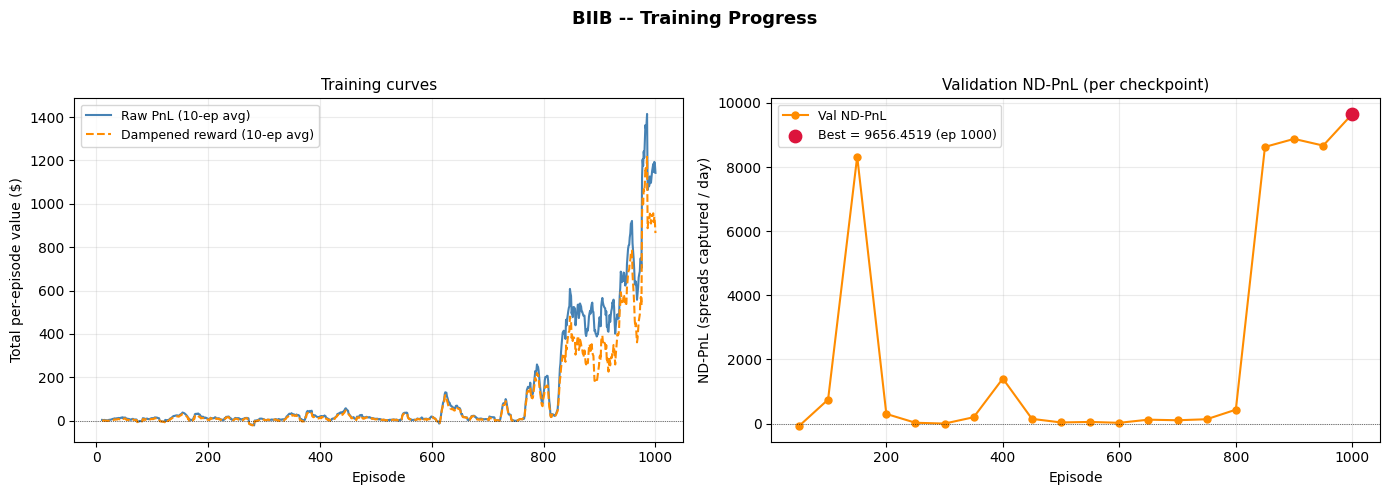


Training complete. Curves saved to /content/drive/MyDrive/market_maker/checkpoints/BIIB_training_curves.png


In [ ]:
# -- Load data ----------------------------------------------------------------
parquet_path = os.path.join(DATA, f"{SYMBOL}.parquet")
if not os.path.exists(parquet_path):
    raise FileNotFoundError(
        f"{parquet_path} not found.\n"
        "Run the Data Download cell above, or upload the parquet file to Drive."
    )

print(f"Loading {parquet_path} ...")
all_days = load_parquet(parquet_path)
train_days, val_days, test_days = train_val_test_split(all_days)
print(f"Events per day (median): {len(all_days[len(all_days)//2]):,}")

# -- Build or resume agent ----------------------------------------------------
WEIGHTS_PATH = os.path.join(CKPT, f"{SYMBOL}_weights.pt")
META_PATH    = os.path.join(CKPT, f"{SYMBOL}_meta.npz")

agent = MarketMakingAgent()

start_ep    = 0
best_val_nd = -np.inf
pnl_log     = []   # raw per-episode Psi(t) sum
reward_log  = []   # dampened reward sum (what the agent actually optimises)
val_eps     = []   # episode numbers at which validation was run
val_nds     = []   # validation ND-PnL at each checkpoint
log_start_ep = 0   # first episode represented by pnl_log/reward_log

def _to_float_list(x):
    return [float(v) for v in np.asarray(x).ravel().tolist()]

def _to_int_list(x):
    return [int(v) for v in np.asarray(x).ravel().tolist()]

def _atomic_save_checkpoint(ep_done: int) -> None:
    weights_tmp = WEIGHTS_PATH + ".tmp"
    meta_tmp    = META_PATH + ".tmp.npz"
    agent.learner.save(weights_tmp)
    np.savez(meta_tmp,
             episode     = int(ep_done),
             learner_episode = int(agent.learner._episode),
             log_start_episode = int(log_start_ep),
             best_val_nd = float(best_val_nd),
             pnl_log     = np.array(pnl_log,    dtype=np.float32),
             reward_log  = np.array(reward_log, dtype=np.float32),
             val_eps     = np.array(val_eps,     dtype=np.int32),
             val_nds     = np.array(val_nds,     dtype=np.float32))
    os.replace(weights_tmp, WEIGHTS_PATH)
    os.replace(meta_tmp, META_PATH)

if os.path.exists(WEIGHTS_PATH):
    try:
        loaded = agent.learner.load(WEIGHTS_PATH)
        if not loaded:
            raise FileNotFoundError(WEIGHTS_PATH)

        if os.path.exists(META_PATH):
            try:
                meta_file = np.load(META_PATH, allow_pickle=False)
            except ValueError:
                # Back-compat for older local metadata saved with object arrays.
                meta_file = np.load(META_PATH, allow_pickle=True)
            with meta_file as meta:
                start_ep    = int(meta["episode"])
                best_val_nd = float(meta["best_val_nd"])
                log_start_ep = int(meta["log_start_episode"]) if "log_start_episode" in meta else 0
                pnl_log     = _to_float_list(meta["pnl_log"])
                reward_log  = (_to_float_list(meta["reward_log"]) if "reward_log" in meta
                               else list(pnl_log))  # back-compat with older checkpoints
                val_eps     = _to_int_list(meta["val_eps"])  if "val_eps"  in meta else []
                val_nds     = _to_float_list(meta["val_nds"]) if "val_nds" in meta else []

            start_ep = min(max(start_ep, 0), TRAIN_EPISODES)
            log_start_ep = min(max(log_start_ep, 0), start_ep)
            expected_log_len = start_ep - log_start_ep
            log_len = min(len(pnl_log), len(reward_log), expected_log_len)
            pnl_log = pnl_log[:log_len]
            reward_log = reward_log[:log_len]
            if log_len != expected_log_len:
                adjusted_ep = log_start_ep + log_len
                print(f"Checkpoint metadata warning: episode={start_ep}, log range={log_start_ep}:{log_start_ep + expected_log_len}; using episode {adjusted_ep}.")
                start_ep = adjusted_ep
                agent.learner._episode = start_ep
        else:
            start_ep = min(max(int(agent.learner._episode), 0), TRAIN_EPISODES)
            log_start_ep = start_ep
            print("Weights checkpoint found without metadata; resuming weights/epsilon only.")

        if agent.learner._episode != start_ep:
            print(f"Checkpoint metadata warning: learner episode {agent.learner._episode} != meta episode {start_ep}; using meta episode.")
            agent.learner._episode = start_ep

        pairs = [(e, v) for e, v in zip(val_eps, val_nds) if 0 < e <= start_ep]
        val_eps = [e for e, _ in pairs]
        val_nds = [v for _, v in pairs]
        if val_nds:
            best_val_nd = max(best_val_nd, max(val_nds))
        print(f"Resumed from episode {start_ep}/{TRAIN_EPISODES}  |  "
              f"epsilon={agent.learner.epsilon:.4f}  |  "
              f"best val ND-PnL={best_val_nd:+.4f}  |  "
              f"logs={log_start_ep}+{len(pnl_log)}")
    except Exception as exc:
        print(f"Checkpoint resume failed ({type(exc).__name__}: {exc}). Starting fresh.")
        agent = MarketMakingAgent()
        start_ep    = 0
        best_val_nd = -np.inf
        pnl_log     = []
        reward_log  = []
        val_eps     = []
        val_nds     = []
        log_start_ep = 0
else:
    print("No checkpoint found -- starting fresh.")

# -- Live plot setup ----------------------------------------------------------
_SMOOTH_W = 10   # rolling average window for training curves

fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{SYMBOL} -- Training Progress", fontsize=13, fontweight="bold")
plt.close(fig)  # prevent auto-display on cell execution; we control display manually

def _refresh_plot():
    ax_train.clear()
    ax_val.clear()

    # Left panel: raw PnL and dampened reward (rolling average)
    if len(pnl_log) >= _SMOOTH_W:
        ker           = np.ones(_SMOOTH_W) / _SMOOTH_W
        smooth_pnl    = np.convolve(pnl_log,    ker, mode="valid")
        smooth_reward = np.convolve(reward_log, ker, mode="valid")
        xs            = np.arange(log_start_ep + _SMOOTH_W, log_start_ep + len(pnl_log) + 1)
        ax_train.plot(xs, smooth_pnl,    color="steelblue",  linewidth=1.5,
                      label=f"Raw PnL ({_SMOOTH_W}-ep avg)")
        ax_train.plot(xs, smooth_reward, color="darkorange", linewidth=1.5,
                      linestyle="--", label=f"Dampened reward ({_SMOOTH_W}-ep avg)")
    ax_train.axhline(0, color="k", linewidth=0.5, linestyle=":")
    ax_train.set_title("Training curves", fontsize=11)
    ax_train.set_xlabel("Episode")
    ax_train.set_ylabel("Total per-episode value ($)")
    ax_train.legend(fontsize=9, loc="upper left")
    ax_train.grid(True, alpha=0.25)

    # Right panel: validation ND-PnL at each checkpoint
    if val_eps:
        ax_val.plot(val_eps, val_nds, "o-", color="darkorange",
                    linewidth=1.5, markersize=5, label="Val ND-PnL")
        best_i = int(np.argmax(val_nds))
        ax_val.scatter(val_eps[best_i], val_nds[best_i],
                       color="crimson", zorder=5, s=80,
                       label=f"Best = {val_nds[best_i]:.4f} (ep {val_eps[best_i]})")
    ax_val.axhline(0, color="k", linewidth=0.5, linestyle=":")
    ax_val.set_title("Validation ND-PnL (per checkpoint)", fontsize=11)
    ax_val.set_xlabel("Episode")
    ax_val.set_ylabel("ND-PnL (spreads captured / day)")
    ax_val.legend(fontsize=9, loc="upper left")
    ax_val.grid(True, alpha=0.25)

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    _display.clear_output(wait=True)
    _display.display(fig)

# -- Training loop with tqdm progress bar ------------------------------------
np.random.seed(0)
random.seed(0)

pbar = tqdm(
    range(start_ep, TRAIN_EPISODES),
    desc    = "Training",
    unit    = "ep",
    initial = start_ep,
    total   = TRAIN_EPISODES,
    dynamic_ncols = True,
)

for ep in pbar:
    day    = random.choice(train_days)
    result = agent.run_episode(day, learn=True)
    pnl_log.append(result.total_pnl)
    reward_log.append(result.total_reward)

    if len(pnl_log) >= _SMOOTH_W:
        pbar.set_postfix(ordered_dict={
            "PnL(10)" : f"{np.mean(pnl_log[-_SMOOTH_W:]):+.2f}",
            "rew(10)" : f"{np.mean(reward_log[-_SMOOTH_W:]):+.2f}",
            "eps"     : f"{agent.learner.epsilon:.4f}",
        })

    if (ep + 1) % CKPT_EVERY == 0:
        # -- Validation pass --
        val_nd = float(np.mean([
            agent.run_episode(d, learn=False).normalised_daily_pnl()
            for d in val_days
        ]))
        best_val_nd = max(best_val_nd, val_nd)
        val_eps.append(ep + 1)
        val_nds.append(val_nd)

        # -- Save checkpoint --
        _atomic_save_checkpoint(ep + 1)

        # -- Refresh live plot --
        _refresh_plot()
        print(f"  [ckpt ep {ep+1:5d}]  val ND-PnL = {val_nd:+.4f}"
              f"  best = {best_val_nd:+.4f}"
              f"  eps = {agent.learner.epsilon:.4f}"
              f"  q_graph = {agent.learner._q_cuda_graph is not None}"
              f"  upd_graphs = {sum(g is not None for g in agent.learner._cuda_graphs)}",
              flush=True)

pbar.close()

# -- Final plot and save ------------------------------------------------------
_refresh_plot()
curve_path = os.path.join(CKPT, f"{SYMBOL}_training_curves.png")
fig.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"\nTraining complete. Curves saved to {curve_path}")